# Decision Trees: How They Work Under the Hood

This notebook introduces Decision Tree classification with the Breast Cancer Wisconsin Diagnostic dataset from `scikit-learn`.

Dataset: Breast Cancer Wisconsin Diagnostic dataset. We predict whether a tumor is **malignant** (`1`) or **benign** (`0`).

We will cover:

- how a Decision Tree makes predictions with feature thresholds;
- how impurity, entropy, and information gain choose a split;
- one manual maths example that reproduces a one-level tree split;
- how to train and inspect a full Decision Tree model;
- how to follow the exact path one example takes through the tree;
- why unrestricted trees can overfit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4.5)

## 1. Load the Breast Cancer Dataset

`load_breast_cancer` is bundled with `scikit-learn`, so the notebook does not need any external data files.

The original target uses `0 = malignant` and `1 = benign`. For consistency with many binary classification examples, we recode it so that:

- `1` means **malignant**, the positive class;
- `0` means **benign**.

In [2]:
cancer = load_breast_cancer(as_frame=True)
raw_df: pd.DataFrame = cancer.frame.copy()

X = raw_df.drop(columns="target")
y = (raw_df["target"] == 0).astype(int)

label_names = {0: "benign", 1: "malignant"}

preview_df = X.copy()
preview_df["diagnosis"] = y.map(label_names)

display(preview_df.head())

display(
    pd.DataFrame({
        "label": pd.Series(label_names),
        "count": y.value_counts().sort_index(),
        "share": y.value_counts(normalize=True).sort_index(),
    })
)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,...,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,...,0.6656,0.7119,0.2654,0.4601,0.1189,malignant
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,...,0.1866,0.2416,0.1860,0.2750,0.0890,malignant
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,...,0.4245,0.4504,0.2430,0.3613,0.0876,malignant
3,11.42,20.38,77.58,386.1,0.1425,0.2839,...,0.8663,0.6869,0.2575,0.6638,0.1730,malignant
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,...,0.2050,0.4000,0.1625,0.2364,0.0768,malignant


,label,count,share
0,benign,357,0.6274
1,malignant,212,0.3726


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "malignant_share": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

split_summary

,rows,malignant_share
train,426,0.3732
test,143,0.3706


## 2. The Basic Idea

A Decision Tree is a sequence of yes/no questions. Each internal node asks a question like:

$$x_j \leq t$$

where `x_j` is one feature and `t` is a threshold. If the answer is yes, the example moves left. If the answer is no, it moves right.

The model chooses questions that make the child nodes more class-pure than the parent node. A pure node contains mostly one class.

## 3. Impurity, Entropy, and Information Gain

For a binary classification node, let `p_0` be the share of benign examples and `p_1` be the share of malignant examples.

One impurity measure is **entropy**:

$$H(node) = -\sum_k p_k \log_2(p_k)$$

Entropy is `0` when the node is pure and larger when the classes are mixed.

Another common impurity measure is **Gini impurity**:

$$Gini(node) = 1 - \sum_k p_k^2$$

`scikit-learn` uses Gini by default. The manual example below uses entropy because information gain is easy to read with entropy, but the split-search idea is the same.

When a split creates left and right child nodes, the tree computes the weighted child entropy:

$$H(children) = \frac{n_L}{n}H(left) + \frac{n_R}{n}H(right)$$

The **information gain** is the impurity reduction:

$$Gain = H(parent) - H(children)$$

A larger gain means the split separated the classes better.

In [4]:
def entropy(labels):
    """Entropy for binary labels encoded as 0/1."""
    counts = np.bincount(np.asarray(labels), minlength=2)
    probabilities = counts[counts > 0] / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))


def class_counts(labels):
    counts = np.bincount(np.asarray(labels), minlength=2)
    return {label_names[i]: int(counts[i]) for i in range(len(counts))}


def split_information_gain(feature_values, labels, threshold):
    feature_values = np.asarray(feature_values)
    labels = np.asarray(labels)

    left_mask = feature_values <= threshold
    right_mask = ~left_mask

    parent_entropy = entropy(labels)
    left_entropy = entropy(labels[left_mask])
    right_entropy = entropy(labels[right_mask])

    n = len(labels)
    weighted_child_entropy = (
        left_mask.sum() / n * left_entropy
        + right_mask.sum() / n * right_entropy
    )

    return {
        "parent_entropy": parent_entropy,
        "left_entropy": left_entropy,
        "right_entropy": right_entropy,
        "weighted_child_entropy": weighted_child_entropy,
        "information_gain": parent_entropy - weighted_child_entropy,
        "left_count": int(left_mask.sum()),
        "right_count": int(right_mask.sum()),
        "left_class_counts": class_counts(labels[left_mask]),
        "right_class_counts": class_counts(labels[right_mask]),
    }


def best_entropy_split(feature_values, labels):
    feature_values = np.asarray(feature_values)
    labels = np.asarray(labels)
    unique_values = np.unique(feature_values)
    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    rows = []
    for threshold in thresholds:
        summary = split_information_gain(feature_values, labels, threshold)
        rows.append({
            "threshold": threshold,
            "information_gain": summary["information_gain"],
            "left_count": summary["left_count"],
            "right_count": summary["right_count"],
        })

    return pd.DataFrame(rows).sort_values("information_gain", ascending=False)

## 4. A Manual Maths Example: One Feature, One Split

To make the split logic visible, we will use only one feature: `worst concave points`.

The code below tests every possible threshold between neighboring observed values in the training data. Then it chooses the threshold with the largest entropy-based information gain.

In [5]:
single_feature = "worst concave points"

candidate_splits = best_entropy_split(X_train[single_feature], y_train)
best_split = candidate_splits.iloc[0]

candidate_splits.head(10)

,threshold,information_gain,left_count,right_count
240,0.1416,0.5356,281,145
249,0.1469,0.5331,290,136
247,0.1455,0.5311,288,138
243,0.1436,0.5285,284,142
241,0.1421,0.5278,282,144
239,0.1411,0.5273,280,146
250,0.1475,0.5256,291,135
248,0.1461,0.5236,289,137
246,0.1452,0.5220,287,139
244,0.1446,0.5208,285,141


In [6]:
best_threshold = best_split["threshold"]
manual_summary = split_information_gain(X_train[single_feature], y_train, best_threshold)

manual_table = pd.DataFrame([
    {
        "node": "parent",
        "n_samples": len(y_train),
        "benign": class_counts(y_train)["benign"],
        "malignant": class_counts(y_train)["malignant"],
        "entropy": manual_summary["parent_entropy"],
    },
    {
        "node": f"left: {single_feature} <= {best_threshold:.4f}",
        "n_samples": manual_summary["left_count"],
        "benign": manual_summary["left_class_counts"]["benign"],
        "malignant": manual_summary["left_class_counts"]["malignant"],
        "entropy": manual_summary["left_entropy"],
    },
    {
        "node": f"right: {single_feature} > {best_threshold:.4f}",
        "n_samples": manual_summary["right_count"],
        "benign": manual_summary["right_class_counts"]["benign"],
        "malignant": manual_summary["right_class_counts"]["malignant"],
        "entropy": manual_summary["right_entropy"],
    },
])

display(manual_table)

print(f"Best threshold: {best_threshold:.6f}")
print(f"Parent entropy: {manual_summary['parent_entropy']:.4f}")
print(f"Weighted child entropy: {manual_summary['weighted_child_entropy']:.4f}")
print(f"Information gain: {manual_summary['information_gain']:.4f}")

,node,n_samples,benign,malignant,entropy
0,parent,426,267,159,0.9531
1,left: worst concave points <= 0.1416,281,256,25,0.4330
2,right: worst concave points > 0.1416,145,11,134,0.3874


Best threshold: 0.141600
Parent entropy: 0.9531
Weighted child entropy: 0.4175
Information gain: 0.5356


This is the exact logic a tree uses at a node: compare many candidate splits, calculate impurity reduction, and keep the split with the biggest gain.

Now we can check that `scikit-learn` chooses the same threshold when we train a one-level tree on this single feature.

In [7]:
stump = DecisionTreeClassifier(
    max_depth=1,
    criterion="entropy",
    random_state=RANDOM_STATE,
)
stump.fit(X_train[[single_feature]], y_train)

sklearn_threshold = stump.tree_.threshold[0]

print(f"Manual threshold:       {best_threshold:.6f}")
print(f"scikit-learn threshold: {sklearn_threshold:.6f}")
print(f"Difference:             {abs(best_threshold - sklearn_threshold):.8f}")

Manual threshold:       0.141600
scikit-learn threshold: 0.141600
Difference:             0.00000000


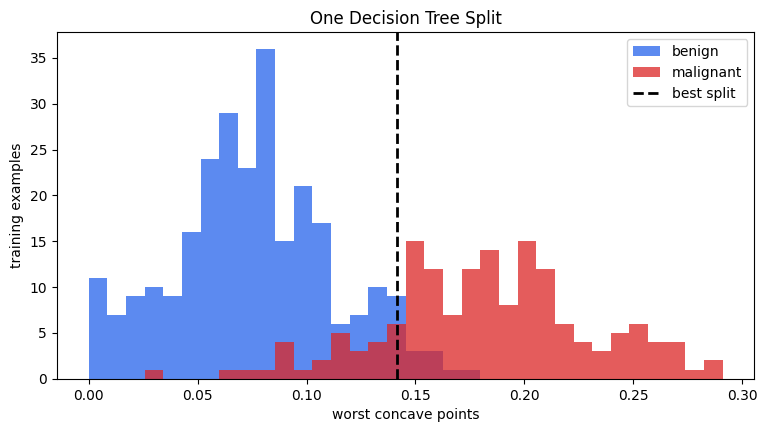

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

bins = np.linspace(X_train[single_feature].min(), X_train[single_feature].max(), 35)

ax.hist(
    X_train.loc[y_train == 0, single_feature],
    bins=bins,
    alpha=0.75,
    label="benign",
    color="#2563EB",
)
ax.hist(
    X_train.loc[y_train == 1, single_feature],
    bins=bins,
    alpha=0.75,
    label="malignant",
    color="#DC2626",
)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=2, label="best split")

ax.set_title("One Decision Tree Split")
ax.set_xlabel(single_feature)
ax.set_ylabel("training examples")
ax.legend()
plt.show()

## 5. Train a Full Decision Tree

A real tree repeats the same split-search process recursively:

1. find the best split at the current node;
2. send examples left or right;
3. repeat inside each child node;
4. stop when a stopping rule is reached.

Decision Trees do not require feature scaling because they only compare one feature to a threshold at a time.

Here we train a small tree with `max_depth=3` and `min_samples_leaf=10` so it remains readable.

In [9]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    criterion="gini",
    random_state=RANDOM_STATE,
)

tree_model.fit(X_train, y_train)

y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

metrics_df = pd.DataFrame({
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
    ],
})

display(metrics_df)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["benign", "malignant"],
))

,split,accuracy
0,train,0.9577
1,test,0.9231


              precision    recall  f1-score   support

      benign       0.89      1.00      0.94        90
   malignant       1.00      0.79      0.88        53

    accuracy                           0.92       143
   macro avg       0.95      0.90      0.91       143
weighted avg       0.93      0.92      0.92       143



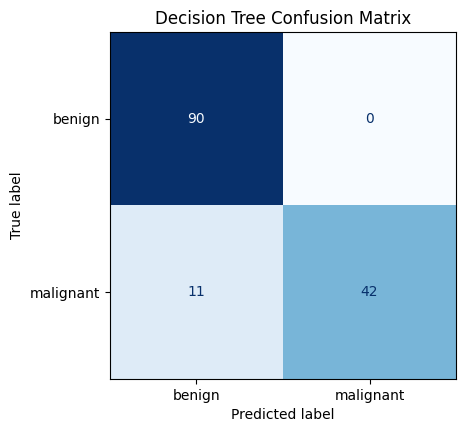

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["benign", "malignant"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Decision Tree Confusion Matrix")
plt.show()

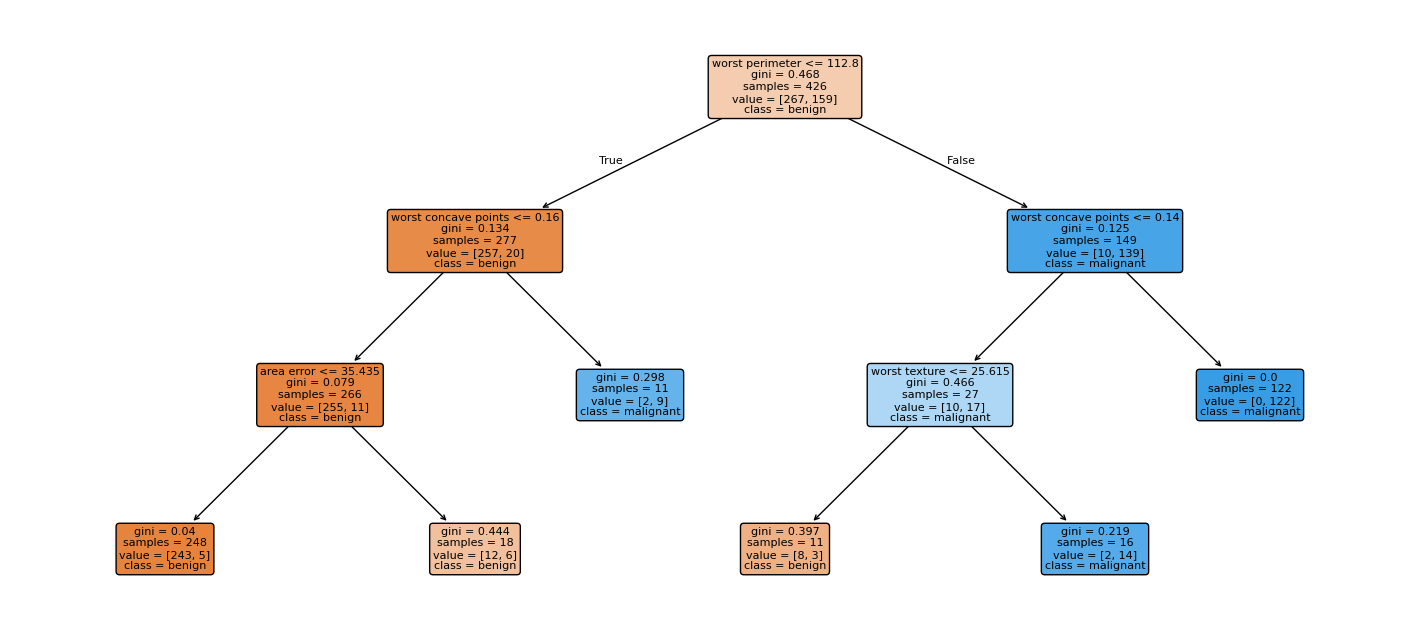

In [11]:
fig, ax = plt.subplots(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["benign", "malignant"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=8,
    ax=ax,
)
plt.show()

## 6. Inspect the Learned Tree as Data

The plot is useful, but the fitted tree is also stored as arrays. Each row below is one node.

For non-leaf nodes, the rule is the question asked at that node. For leaf nodes, the prediction is the majority class among the training examples that reached that leaf.

In [12]:
def node_class_counts(tree, node_id):
    values = tree.value[node_id][0]
    if np.isclose(values.sum(), 1.0):
        values = values * tree.weighted_n_node_samples[node_id]
    return values


tree = tree_model.tree_
node_rows = []

for node_id in range(tree.node_count):
    is_leaf = tree.children_left[node_id] == tree.children_right[node_id]
    values = node_class_counts(tree, node_id)
    predicted_class = int(np.argmax(values))

    if is_leaf:
        rule = "leaf"
    else:
        feature_name = X_train.columns[tree.feature[node_id]]
        rule = f"{feature_name} <= {tree.threshold[node_id]:.4f}"

    node_rows.append({
        "node": node_id,
        "rule": rule,
        "samples": int(tree.n_node_samples[node_id]),
        "gini": tree.impurity[node_id],
        "benign": values[0],
        "malignant": values[1],
        "prediction": label_names[predicted_class],
    })

pd.DataFrame(node_rows)

,node,rule,samples,gini,benign,malignant,prediction
0,0,worst perimeter <= 112.8000,426,0.4679,267.0,159.0,benign
1,1,worst concave points <= 0.1603,277,0.1340,257.0,20.0,benign
2,2,area error <= 35.4350,266,0.0793,255.0,11.0,benign
3,3,leaf,248,0.0395,243.0,5.0,benign
4,4,leaf,18,0.4444,12.0,6.0,benign
5,5,leaf,11,0.2975,2.0,9.0,malignant
6,6,worst concave points <= 0.1398,149,0.1252,10.0,139.0,malignant
7,7,worst texture <= 25.6150,27,0.4664,10.0,17.0,malignant
8,8,leaf,11,0.3967,8.0,3.0,benign
9,9,leaf,16,0.2188,2.0,14.0,malignant


## 7. Follow One Prediction Through the Tree

A tree prediction is transparent: one example follows one path from the root node to a leaf node.

The next cell picks one malignant test example and prints the exact rules it follows.

In [13]:
sample_index = y_test[y_test == 1].index[0]
sample = X_test.loc[[sample_index]]
actual_label = y_test.loc[sample_index]

predicted_label = tree_model.predict(sample)[0]
predicted_proba = tree_model.predict_proba(sample)[0]

node_indicator = tree_model.decision_path(sample)
leaf_id = tree_model.apply(sample)[0]
path_node_ids = node_indicator.indices[
    node_indicator.indptr[0]:node_indicator.indptr[1]
]

path_rows = []
for node_id in path_node_ids:
    is_leaf = tree.children_left[node_id] == tree.children_right[node_id]

    if is_leaf:
        path_rows.append({
            "node": node_id,
            "feature": "leaf",
            "sample_value": np.nan,
            "threshold": np.nan,
            "decision": f"predict {label_names[predicted_label]}",
        })
        continue

    feature_index = tree.feature[node_id]
    feature_name = X_train.columns[feature_index]
    threshold = tree.threshold[node_id]
    sample_value = sample.iloc[0, feature_index]
    decision = "go left" if sample_value <= threshold else "go right"

    path_rows.append({
        "node": node_id,
        "feature": feature_name,
        "sample_value": sample_value,
        "threshold": threshold,
        "decision": decision,
    })

print(f"Test row index: {sample_index}")
print(f"Actual label: {label_names[actual_label]}")
print(f"Predicted label: {label_names[predicted_label]}")
print(f"Predicted probabilities: benign={predicted_proba[0]:.3f}, malignant={predicted_proba[1]:.3f}")
print(f"Leaf node: {leaf_id}")

display(pd.DataFrame(path_rows))

Test row index: 12
Actual label: malignant
Predicted label: malignant
Predicted probabilities: benign=0.000, malignant=1.000
Leaf node: 10


,node,feature,sample_value,threshold,decision
0,0,worst perimeter,151.7000,112.8000,go right
1,6,worst concave points,0.1767,0.1398,go right
2,10,leaf,NaN,NaN,predict malignant


## 8. Overfitting: Why Tree Size Matters

Decision Trees are flexible. If we allow a tree to keep splitting until every leaf is almost pure, it can memorize the training data.

Useful controls include:

- `max_depth`: maximum number of questions from root to leaf;
- `min_samples_leaf`: minimum number of training examples allowed in each leaf;
- `min_samples_split`: minimum number of examples needed before a node may split;
- `ccp_alpha`: cost-complexity pruning strength.

In [14]:
tree_configs = [
    ("stump", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)),
    ("depth-limited", DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE)),
    ("unrestricted", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]

comparison_rows = []
for model_name, model in tree_configs:
    model.fit(X_train, y_train)
    comparison_rows.append({
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
    })

pd.DataFrame(comparison_rows)

,model,train_accuracy,test_accuracy,depth,leaves
0,stump,0.9296,0.8881,1,2
1,depth-limited,0.9577,0.9231,3,6
2,unrestricted,1.0000,0.9580,8,21


,feature,importance
22,worst perimeter,0.8425
27,worst concave points,0.1104
21,worst texture,0.0278
13,area error,0.0193
0,mean radius,0.0000
16,concavity error,0.0000
28,worst symmetry,0.0000
26,worst concavity,0.0000
25,worst compactness,0.0000
24,worst smoothness,0.0000


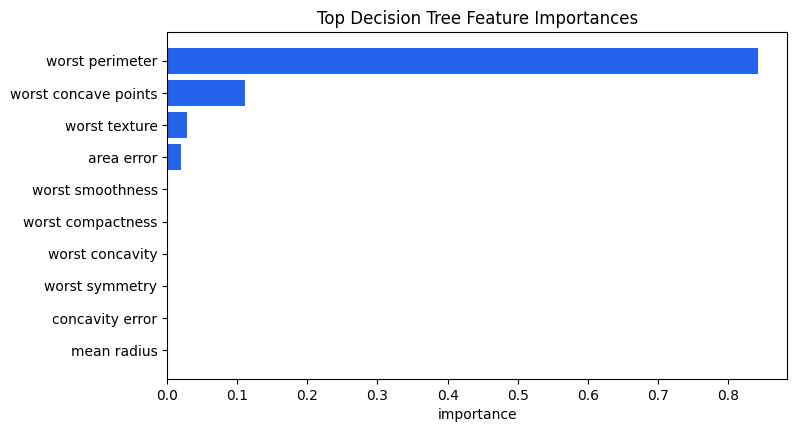

In [15]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df.head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
top_importance = importance_df.head(10).sort_values("importance")
ax.barh(top_importance["feature"], top_importance["importance"], color="#2563EB")
ax.set_title("Top Decision Tree Feature Importances")
ax.set_xlabel("importance")
plt.show()

## 9. Main Takeaways

1. A Decision Tree predicts by sending each example through a sequence of threshold rules.
2. At each node, the model tries candidate splits and keeps the split with the largest impurity reduction.
3. Entropy and Gini are two common impurity measures. Both reward splits that create purer child nodes.
4. Decision Trees do not need feature scaling because each split uses one feature at a time.
5. The fitted tree can be inspected as rules, arrays, a plot, feature importances, and individual prediction paths.
6. Unrestricted trees can overfit, so depth, leaf size, and pruning are important regularization tools.